# EfficientNet — skin disease classification

Same workflow as `resnet50_skin_disease_custom.ipynb`, but using **torchvision EfficientNet** pretrained on ImageNet, with the classifier head replaced for **`NUM_CLASSES`** labels.

- Load images from `DatasetSkinDisease` **`train/`** / **`test/`** folders.
- **Label** = parent folder name (snake_case), **`class_id`** for PyTorch.

Run with the working directory set to **`DeepLearningProject`**.


In [6]:
from __future__ import annotations

import re
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn

IMAGE_SUFFIXES = {".jpg", ".jpeg", ".JPG", ".JPEG", ".png", ".PNG"}


def folder_to_label(folder_name: str) -> str:
    s = re.sub(r"([a-z0-9])([A-Z])", r"\1_\2", folder_name)
    return s.replace("__", "_").lower()


def find_dataset_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    candidates = [
        start / "DatasetSkinDisease" / "SkinDisease" / "SkinDisease",
        start / "DatasetSkinDisease",
        start,
    ]
    for c in candidates:
        if (c / "train").is_dir() and (c / "test").is_dir():
            return c.resolve()
    raise FileNotFoundError(
        "Could not find train/ and test/. Set DATASET_ROOT manually."
    )


DATASET_ROOT = find_dataset_root()
TRAIN_DIR = DATASET_ROOT / "train"
TEST_DIR = DATASET_ROOT / "test"
print("DATASET_ROOT:", DATASET_ROOT)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    print(
        f"GPU: {torch.cuda.get_device_name(0)} | CUDA {torch.version.cuda} | {torch.__version__}"
    )
else:
    print(f"CPU | {torch.__version__}")


DATASET_ROOT: D:\DeepLearningProject\DatasetSkinDisease\SkinDisease\SkinDisease
GPU: NVIDIA GeForce RTX 3080 | CUDA 12.4 | 2.6.0+cu124


In [7]:
def collect_split(split_dir: Path, split_name: str) -> pd.DataFrame:
    rows: list[dict] = []
    if not split_dir.is_dir():
        raise FileNotFoundError(split_dir)
    for class_dir in sorted(p for p in split_dir.iterdir() if p.is_dir()):
        folder_name = class_dir.name
        label = folder_to_label(folder_name)
        for f in class_dir.iterdir():
            if f.is_file() and f.suffix in IMAGE_SUFFIXES:
                rows.append(
                    {
                        "path": f.resolve(),
                        "path_str": str(f.resolve()),
                        "split": split_name,
                        "folder_name": folder_name,
                        "label": label,
                    }
                )
    return pd.DataFrame(rows)


train_df = collect_split(TRAIN_DIR, "train")
test_df = collect_split(TEST_DIR, "test")
manifest = pd.concat([train_df, test_df], ignore_index=True)

print("Train:", len(train_df), "| Test:", len(test_df), "| Total:", len(manifest))


Train: 13898 | Test: 1546 | Total: 15444


In [8]:
class_names = sorted(train_df["label"].unique())
label_to_id = {lab: i for i, lab in enumerate(class_names)}

train_df = train_df.copy()
test_df = test_df.copy()
train_df["class_id"] = train_df["label"].map(label_to_id)
test_df["class_id"] = test_df["label"].map(label_to_id)

missing_test = test_df["class_id"].isna().sum()
if missing_test:
    raise ValueError(
        f"{missing_test} test labels missing from train; check folder names."
    )

train_df["class_id"] = train_df["class_id"].astype("int64")
test_df["class_id"] = test_df["class_id"].astype("int64")
manifest = pd.concat([train_df, test_df], ignore_index=True)

NUM_CLASSES = len(class_names)
print("NUM_CLASSES:", NUM_CLASSES)


NUM_CLASSES: 22


In [9]:
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

PIN_MEMORY = device.type == "cuda"


class SkinManifestDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform):
        self.paths = df["path"].tolist()
        self.targets = df["class_id"].astype(int).tolist()
        self.transform = transform

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int):
        from PIL import Image

        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, self.targets[idx]


IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
IMG_SIZE = 224

train_tfms = transforms.Compose(
    [
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(
            brightness=0.15, contrast=0.15, saturation=0.1, hue=0.05
        ),
        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.2
        ),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        transforms.RandomErasing(p=0.15, scale=(0.02, 0.12)),
    ]
)

eval_tfms = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)

BATCH_SIZE = 32
NUM_WORKERS = 0

train_loader = DataLoader(
    SkinManifestDataset(train_df, train_tfms),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    SkinManifestDataset(test_df, eval_tfms),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print("train batches:", len(train_loader), "| test batches:", len(test_loader))


train batches: 435 | test batches: 49


## EfficientNet training (optimized)

This section fine-tunes **EfficientNet-B0** with ImageNet weights and a replaced classifier head for **`NUM_CLASSES`** labels. It uses the same transfer-learning optimizations as the ResNet-50 notebook: head-first training, two learning rates, label smoothing, gradient clipping, cosine LR schedule, plus best-checkpoint by test loss and early stopping.


In [10]:
from copy import deepcopy

from tqdm.auto import tqdm
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# --- hyperparameters (tune these) ---
EPOCHS = 50
FREEZE_EPOCHS = 3  # train head first, then fine-tune whole model

LR_HEAD = 3e-4
LR_BACKBONE = 1e-4
WEIGHT_DECAY = 0.05
LABEL_SMOOTHING = 0.1
GRAD_CLIP_NORM = 1.0

EARLY_STOP_PATIENCE = 8

torch.manual_seed(42)
if device.type == "cuda":
    torch.cuda.manual_seed_all(42)

# Model (ImageNet pretrained)
weights = EfficientNet_B0_Weights.IMAGENET1K_V1
model = efficientnet_b0(weights=weights)

# Replace classifier for NUM_CLASSES
# EfficientNet-B0 classifier is typically: Sequential(Dropout, Linear)
if isinstance(model.classifier, nn.Sequential) and isinstance(model.classifier[-1], nn.Linear):
    model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, NUM_CLASSES)
else:
    model.classifier = nn.Sequential(nn.Dropout(p=0.2, inplace=True), nn.Linear(1280, NUM_CLASSES))

model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

# Freeze backbone initially (everything except classifier)
for name, p in model.named_parameters():
    if not name.startswith("classifier"):
        p.requires_grad = False

optimizer = torch.optim.AdamW(
    [
        {"params": model.classifier.parameters(), "lr": LR_HEAD},
    ],
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)

use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)


def train_one_epoch() -> float:
    model.train()
    total_loss = 0.0
    n = 0
    for images, labels in tqdm(train_loader, desc="train", leave=False):
        images = images.to(device, non_blocking=PIN_MEMORY)
        labels = labels.to(device, non_blocking=PIN_MEMORY)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            logits = model(images)
            loss = criterion(logits, labels)

        if use_amp:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            optimizer.step()

        total_loss += loss.item() * labels.size(0)
        n += labels.size(0)

    return total_loss / max(n, 1)


@torch.inference_mode()
def evaluate() -> tuple[float, float]:
    model.eval()
    correct = 0
    total = 0
    run_loss = 0.0

    for images, labels in tqdm(test_loader, desc="test", leave=False):
        images = images.to(device, non_blocking=PIN_MEMORY)
        labels = labels.to(device, non_blocking=PIN_MEMORY)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            logits = model(images)
            loss = criterion(logits, labels)

        run_loss += loss.item() * labels.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    acc = correct / max(total, 1)
    avg_loss = run_loss / max(total, 1)
    return avg_loss, acc


best_te_loss = float("inf")
best_state = deepcopy(model.state_dict())
best_epoch = 0
epochs_no_improve = 0

for epoch in range(1, EPOCHS + 1):
    if epoch == FREEZE_EPOCHS + 1:
        for p in model.parameters():
            p.requires_grad = True

        backbone_params = [p for n, p in model.named_parameters() if not n.startswith("classifier")]
        head_params = list(model.classifier.parameters())

        optimizer = torch.optim.AdamW(
            [
                {"params": head_params, "lr": LR_HEAD},
                {"params": backbone_params, "lr": LR_BACKBONE},
            ],
            weight_decay=WEIGHT_DECAY,
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=EPOCHS - epoch + 1, eta_min=1e-6
        )

    tr_loss = train_one_epoch()
    te_loss, te_acc = evaluate()
    scheduler.step()

    lrs = [g["lr"] for g in optimizer.param_groups]
    lr_str = ",".join([f"{lr:.2e}" for lr in lrs])

    print(
        f"epoch {epoch}/{EPOCHS}  lr=[{lr_str}]  train_loss={tr_loss:.4f}  "
        f"test_loss={te_loss:.4f}  test_acc={te_acc:.4f}"
    )

    if te_loss < best_te_loss - 1e-5:
        best_te_loss = te_loss
        best_state = deepcopy(model.state_dict())
        best_epoch = epoch
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(
            f"Early stop at epoch {epoch} (best epoch {best_epoch}, test_loss={best_te_loss:.4f})"
        )
        break

model.load_state_dict(best_state)
print(f"Using best weights from epoch {best_epoch} (test_loss={best_te_loss:.4f})")


train:   0%|          | 0/435 [00:00<?, ?it/s]

test:   0%|          | 0/49 [00:00<?, ?it/s]

epoch 1/50  lr=[3.00e-04]  train_loss=2.6357  test_loss=2.3505  test_acc=0.3765


train:   0%|          | 0/435 [00:00<?, ?it/s]

test:   0%|          | 0/49 [00:00<?, ?it/s]

...

test:   0%|          | 0/49 [00:00<?, ?it/s]

epoch 49/50  lr=[1.33e-06,1.11e-06]  train_loss=0.6912  test_loss=1.2422  test_acc=0.7878


train:   0%|          | 0/435 [00:00<?, ?it/s]

test:   0%|          | 0/49 [00:00<?, ?it/s]

epoch 50/50  lr=[1.00e-06,1.00e-06]  train_loss=0.6912  test_loss=1.2336  test_acc=0.7917
Using best weights from epoch 43 (test_loss=1.2269)


## Confusion matrix (test set)

The next cell runs the trained **EfficientNet** `model` on `test_loader` and plots the confusion matrix (rows = true class, columns = predicted class).


predict:   0%|          | 0/49 [00:00<?, ?it/s]

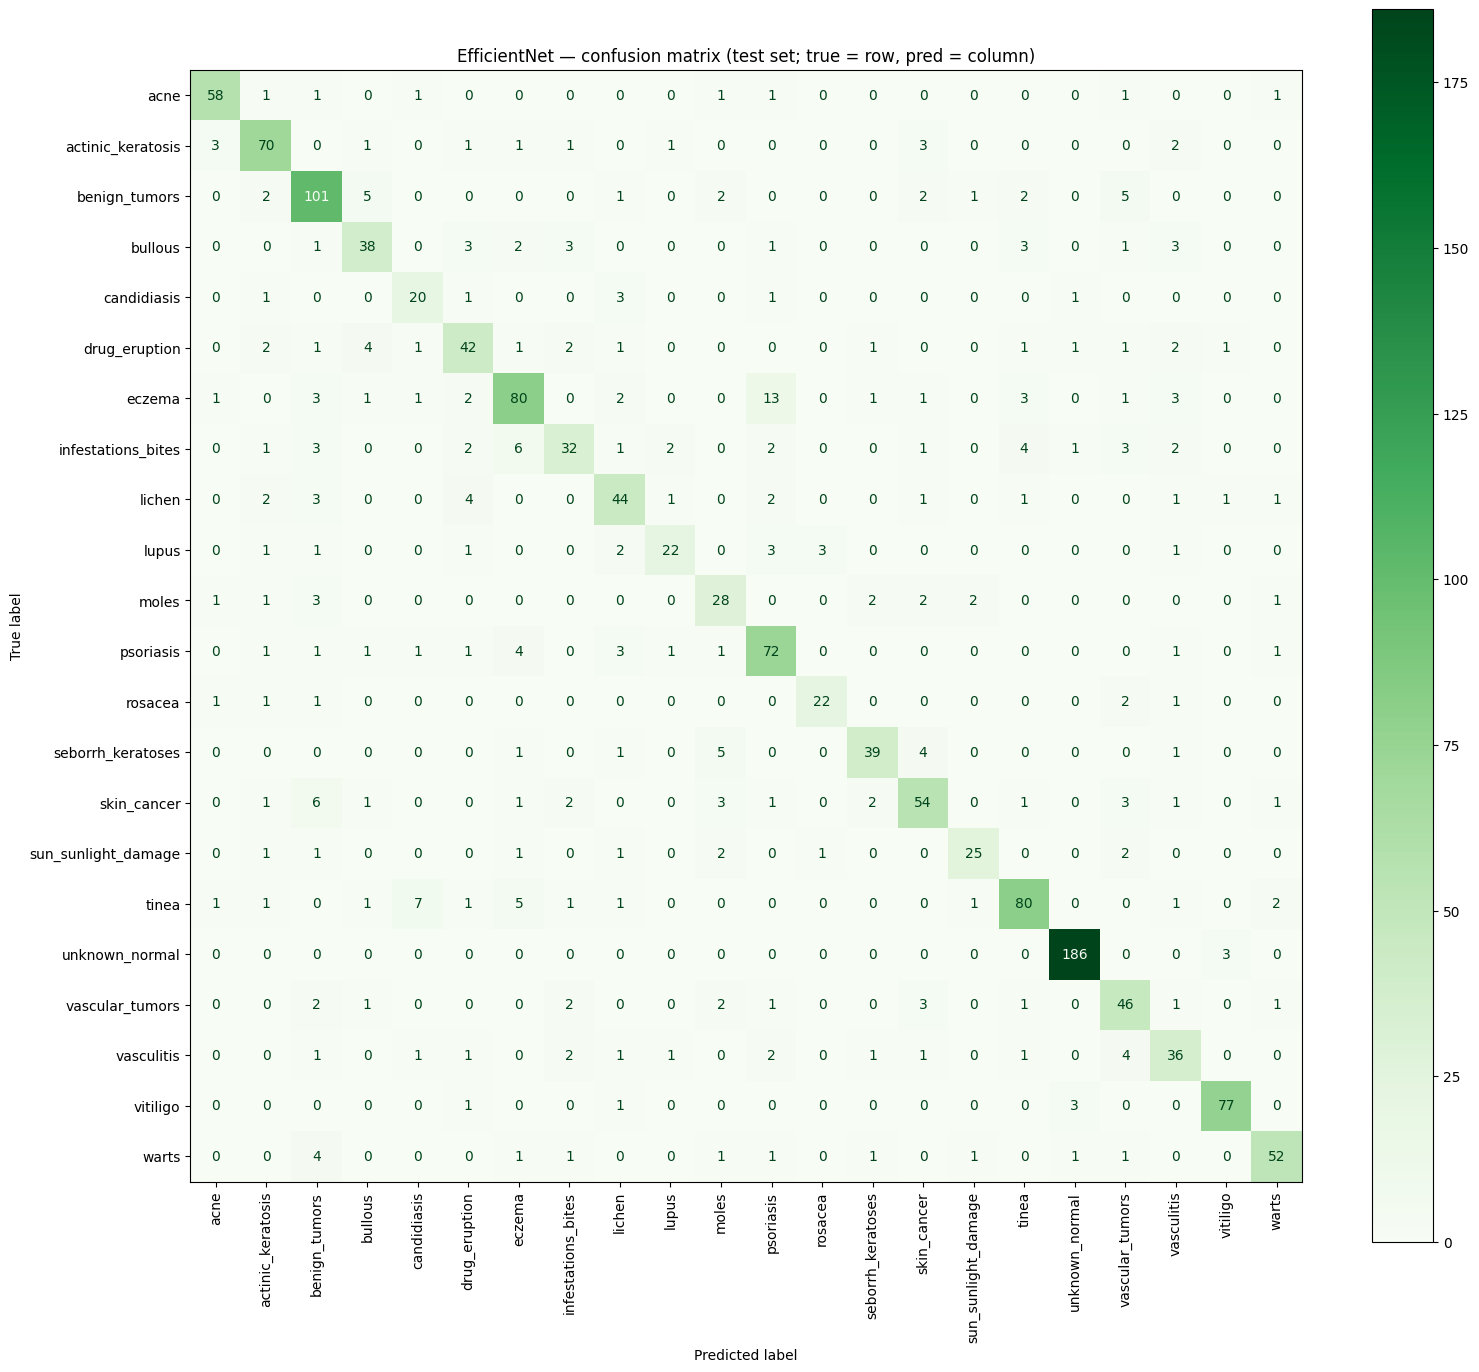

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


@torch.no_grad()
def collect_test_predictions():
    model.eval()
    y_true: list[int] = []
    y_pred: list[int] = []
    for images, labels in tqdm(test_loader, desc="predict", leave=False):
        images = images.to(device, non_blocking=PIN_MEMORY)
        labels = labels.to(device, non_blocking=PIN_MEMORY)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            logits = model(images)
        pred = logits.argmax(dim=1)
        y_true.extend(labels.cpu().numpy().tolist())
        y_pred.extend(pred.cpu().numpy().tolist())
    return np.asarray(y_true), np.asarray(y_pred)


y_true, y_pred = collect_test_predictions()
cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES, dtype=int))

fig, ax = plt.subplots(figsize=(16, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Greens", colorbar=True, xticks_rotation=90, values_format="d")
ax.set_title("EfficientNet — confusion matrix (test set; true = row, pred = column)")
plt.tight_layout()
plt.show()
